# Lecture 08: LLM Post-Training — SFT · Reward Model · PPO

**Paper**: [InstructGPT: Training language models to follow instructions with human feedback](https://arxiv.org/abs/2203.02155) (Ouyang et al., OpenAI, 2022)

**Base model**: GPT-2 small (124 M)

---

## InstructGPT Three-Stage Pipeline

```
┌──────────────────────────────────────────────────────────────────────┐
│  STAGE 1 — Supervised Fine-Tuning (SFT)                              │
│                                                                      │
│  Pretrained GPT-2 ──[human demonstrations, 8 epochs]──► SFT Model    │
└──────────────────────────────────────────────────────────────────────┘
                              │
                              ▼
┌──────────────────────────────────────────────────────────────────────┐
│  STAGE 2 — Reward Model (RM)                                         │
│                                                                      │
│  SFT Model ──[human preference pairs, 1 epoch]──► RM (scalar r)      │
│               Bradley-Terry objective                                │
└──────────────────────────────────────────────────────────────────────┘
                              │
                              ▼
┌──────────────────────────────────────────────────────────────────────┐
│  STAGE 3 — RLHF via PPO                                              │
│                                                                      │
│  SFT policy + RM reward + KL penalty ──► Aligned Model               │
└──────────────────────────────────────────────────────────────────────┘
```

> **Key idea**: Pretraining learns *how* to produce fluent text. SFT teaches *what format* an answer should take. RM captures *what humans prefer*. PPO optimises directly against human preference, with a KL penalty to prevent reward hacking.


## Learning Objectives

1. **SFT** — fine-tune GPT-2 on demonstrations; understand response-only loss masking
2. **RM** — build a scalar reward model with Bradley-Terry pairwise loss
3. **PPO** — implement the full RLHF loop: rollout → KL-penalised reward → GAE → clipped update
4. **WandB** — track all three stages with a shared run
5. **Critique** — understand reward hacking, KL constraints, and annotation cost


In [1]:
import os, time, json, math, random

from dataclasses import dataclass, asdict
from typing import List, Optional, Tuple

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim import AdamW

os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"
device = 'cuda:2' # change to cuda:0 if you have only one gpu

from transformers import (
    GPT2LMHeadModel, GPT2Model, GPT2Tokenizer,
    get_linear_schedule_with_warmup, set_seed,
)
from datasets import load_dataset
from tqdm.auto import tqdm
import wandb

set_seed(42)
random.seed(42)
np.random.seed(42)
print("Imports done.")

Imports done.


## Hyperparameter Configuration

Values follow InstructGPT Table 6, scaled for GPT-2.

In [2]:
@dataclass
class Config:
    # General
    model_name:      str   = "gpt2"
    output_dir:      str   = "./checkpoints"
    run_name:        str   = f"instructgpt-gpt2-full-{time.strftime('%Y%m%d_%H%M%S')}"

    # SFT  (InstructGPT §3.1) — full Alpaca (52,002 examples)
    sft_dataset:     str             = "tatsu-lab/alpaca"
    sft_n_samples:   Optional[int]   = None        # None = full dataset
    sft_val_size:    int             = 1_000       # held-out for val perplexity
    sft_epochs:      int             = 8           # 3 over 52K ≈ 4× the orig 8×5K
    sft_batch_size:  int             = 32
    sft_lr:          float           = 9.65e-6
    sft_warmup:      float           = 0.03        # smaller fraction for longer run
    sft_weight_decay:float           = 0.01
    sft_max_len:     int             = 512

    # Reward Model (InstructGPT §3.2) — full HH-RLHF (160,800 pairs)
    rm_dataset:      str             = "Anthropic/hh-rlhf"
    rm_n_samples:    Optional[int]   = None        # None = full train split
    rm_epochs:       int             = 1           # 1 epoch prevents overfitting
    rm_batch_size:   int             = 32
    rm_lr:           float           = 9e-6
    rm_max_len:      int             = 512
    rm_eval_n:       int             = 4_000       # # of test pairs for accuracy

    # PPO  (InstructGPT §3.3 / Table 6)
    ppo_n_prompts:   Optional[int]   = None       # prompt pool (None = all alpaca)
    ppo_steps:       int             = 200         # up from 100
    ppo_batch_size:  int             = 32
    ppo_epochs:      int             = 4
    ppo_lr:          float           = 9.65e-6
    kl_coef:         float           = 0.1
    clip_eps:        float           = 0.2
    gamma:           float           = 1.0
    gae_lambda:      float           = 0.95
    vf_coef:         float           = 0.1
    max_new_tokens:  int             = 64

    # Evaluation
    eval_n_prompts:  int             = 200         # RM-scored prompts per model

cfg = Config()
os.makedirs(cfg.output_dir, exist_ok=True)
print(json.dumps(asdict(cfg), indent=2))

{
  "model_name": "gpt2",
  "output_dir": "./checkpoints",
  "run_name": "instructgpt-gpt2-full-20260512_075630",
  "sft_dataset": "tatsu-lab/alpaca",
  "sft_n_samples": null,
  "sft_val_size": 1000,
  "sft_epochs": 8,
  "sft_batch_size": 32,
  "sft_lr": 9.65e-06,
  "sft_warmup": 0.03,
  "sft_weight_decay": 0.01,
  "sft_max_len": 512,
  "rm_dataset": "Anthropic/hh-rlhf",
  "rm_n_samples": null,
  "rm_epochs": 1,
  "rm_batch_size": 32,
  "rm_lr": 9e-06,
  "rm_max_len": 512,
  "rm_eval_n": 4000,
  "ppo_n_prompts": null,
  "ppo_steps": 200,
  "ppo_batch_size": 32,
  "ppo_epochs": 4,
  "ppo_lr": 9.65e-06,
  "kl_coef": 0.1,
  "clip_eps": 0.2,
  "gamma": 1.0,
  "gae_lambda": 0.95,
  "vf_coef": 0.1,
  "max_new_tokens": 64,
  "eval_n_prompts": 200
}


## Weights & Biases

All three training stages log to a **single WandB run** with prefix-namespaced keys:
`sft/loss`, `rm/accuracy`, `ppo/reward_mean`, etc.

Set your API key before running:
```bash
export WANDB_API_KEY=your_key_here
```
or call `wandb.login()` interactively.


In [3]:
# wandb.login()  # uncomment for interactive login
wandb.init(
    project  = "instructgpt-lecture",
    name     = cfg.run_name,
    config   = asdict(cfg),
    tags     = ["lecture", "gpt2", "sft", "rm", "ppo"],
    notes    = "InstructGPT pipeline demo: GPT-2 SFT → RM → PPO",
)
print(f"WandB run: {wandb.run.url}")

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /mnt/data/baojian/.netrc.
wandb: Currently logged in as: baojian (baojian-fudan-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


WandB run: https://wandb.ai/baojian-fudan-university/instructgpt-lecture/runs/k8nsql57


---
# Stage 1: Supervised Fine-Tuning (SFT)

> *"We trained SFT models on our demonstration data for 16 epochs, using a cosine learning rate decay, and selected the final SFT model based on the RM score on the validation set."*
> — InstructGPT §3.1

### Loss (response tokens only)

$$\mathcal{L}_{\text{SFT}} = -\sum_{t \in \text{response}} \log p_{\theta}(x_t \mid x_{<t})$$

Prompt tokens get label `−100` so they are **ignored** by `CrossEntropyLoss`.


## Popular SFT Datasets

| Dataset | Size | Source | Key property |
|---------|------|--------|-------------|
| **Stanford Alpaca** | 52 K | GPT-3 self-instruct | Easy to load; instruction diversity |
| **ShareGPT** | ~90 K | Real ChatGPT conversations | Multi-turn; high quality |
| **OpenAssistant (OASST1)** | 161 K | Human annotators | Multilingual; on HuggingFace |
| **Databricks Dolly 15 K** | 15 K | Human employees | Permissive license |
| **FLAN v2** | 1.8 B tokens | Academic NLP tasks | Large scale |
| **WizardLM Evol-Instruct** | 250 K | GPT-4 evolved | Complex reasoning |
| **UltraChat** | 1.5 M | GPT-3.5-turbo | Multi-turn dialogue |
| **Open-Platypus** | 25 K | Curated STEM + logic | High reasoning quality |
| **MetaMath** | 395 K | GPT-4 augmented | Math-focused |
| **Orca 1/2** | 500 K–1 M | GPT-4 with traces | Reasoning diversity |

**Demo uses**: Stanford Alpaca — simple format, widely cited, HuggingFace hosted.


In [4]:
print("Loading Stanford Alpaca...")
alpaca_full = load_dataset(cfg.sft_dataset, split="train")
n_full = len(alpaca_full)

if cfg.sft_n_samples is None or cfg.sft_n_samples >= n_full:
    alpaca_subset = alpaca_full
else:
    alpaca_subset = alpaca_full.select(range(cfg.sft_n_samples))

# Split off a held-out val set (last `sft_val_size` rows of the chosen subset).
val_size = min(cfg.sft_val_size, max(1, len(alpaca_subset) // 10))
train_idx = list(range(0, len(alpaca_subset) - val_size))
val_idx   = list(range(len(alpaca_subset) - val_size, len(alpaca_subset)))
alpaca_data     = alpaca_subset.select(train_idx)
alpaca_val_data = alpaca_subset.select(val_idx)

print(f"SFT train: {len(alpaca_data)}  |  val: {len(alpaca_val_data)}  |  full: {n_full}")
s = alpaca_data[1]
print(f"\nInstruction: {s['instruction']}")
print(f"Input:       {s.get('input','')[:80]}")
print(f"Output:      {s['output'][:200]}")

Loading Stanford Alpaca...


SFT train: 51002  |  val: 1000  |  full: 52002

Instruction: What are the three primary colors?
Input:       
Output:      The three primary colors are red, blue, and yellow.


In [5]:
def format_prompt(instruction: str, input_text: str = "", output: str = "") -> str:
    """Alpaca-style prompt template."""
    if input_text.strip():
        return (f"### Instruction:\n{instruction}\n\n"
                f"### Input:\n{input_text}\n\n"
                f"### Response:\n{output}")
    return f"### Instruction:\n{instruction}\n\n### Response:\n{output}"

# Quick visual check
print(format_prompt("Convert to uppercase.", "hello world", "HELLO WORLD"))

### Instruction:
Convert to uppercase.

### Input:
hello world

### Response:
HELLO WORLD


## Prompt Templates in Practice

Every SFT pipeline wraps (instruction, response) in a fixed template. The exact format differs per model family — what matters is using the **same template** at SFT, RM training, PPO, *and* inference.

| Model | Template |
|-------|----------|
| **Alpaca** (this demo) | `### Instruction:\n...\n### Response:\n` |
| **LLaMA-2 Chat** | `[INST] ... [/INST] with <<SYS>> tags` |
| **Gemma** | `<start_of_turn>user\n{user}<end_of_turn>\n` |
| **DeepSeek** | `User: {user}\n\nAssistant:` |

Modern HuggingFace checkpoints ship the template inside `tokenizer_config.json`:
```python
# inference
tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

# SFT training: mask everything before the assistant turn
prompt_ids = tokenizer.apply_chat_template(messages[:-1], tokenize=False, add_generation_prompt=True)
prompt_len = len(tokenizer.encode(prompt_ids))
labels[:prompt_len] = -100   # same idea as our SFTDataset below
```

In [6]:
class SFTDataset(Dataset):
    """Tokenises instruction-response pairs; masks prompt labels to -100."""

    def __init__(self, data, tokenizer, max_length: int = 512):
        self.samples = []
        tokenizer.padding_side = "right"
        for item in tqdm(data, desc="Tokenising SFT"):
            instruction = item["instruction"]
            inp         = item.get("input", "") or ""
            output      = item["output"]
            prompt_str = format_prompt(instruction, inp)           # no output
            full_str   = format_prompt(instruction, inp, output) + tokenizer.eos_token
            prompt_ids = tokenizer.encode(prompt_str, add_special_tokens=True)
            full_enc   = tokenizer(
                full_str, max_length=max_length, truncation=True,
                padding="max_length", return_tensors="pt",
            )
            input_ids  = full_enc["input_ids"].squeeze(0)
            attn_mask  = full_enc["attention_mask"].squeeze(0)
            labels = input_ids.clone()
            labels[: min(len(prompt_ids), max_length)] = -100     # mask prompt
            self.samples.append({
                "input_ids":      input_ids,
                "attention_mask": attn_mask,
                "labels":         labels,
            })

    def __len__(self):  return len(self.samples)
    def __getitem__(self, i): return self.samples[i]


In [7]:
print("Loading GPT-2...")
tokenizer = GPT2Tokenizer.from_pretrained(cfg.model_name)
tokenizer.pad_token    = tokenizer.eos_token
tokenizer.pad_token_id = tokenizer.eos_token_id

sft_model = GPT2LMHeadModel.from_pretrained(cfg.model_name).to(device)
sft_model.config.pad_token_id = tokenizer.eos_token_id

n = sum(p.numel() for p in sft_model.parameters())
print(f"GPT-2 parameters: {n/1e6:.1f} M")

Loading GPT-2...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT-2 parameters: 124.4 M


In [8]:
sft_dataset      = SFTDataset(alpaca_data,     tokenizer, cfg.sft_max_len)
sft_val_dataset  = SFTDataset(alpaca_val_data, tokenizer, cfg.sft_max_len)
sft_loader       = DataLoader(sft_dataset, batch_size=cfg.sft_batch_size,
                              shuffle=True, pin_memory=True, num_workers=2)
sft_val_loader   = DataLoader(sft_val_dataset, batch_size=cfg.sft_batch_size,
                              shuffle=False, pin_memory=True, num_workers=2)

total_steps  = len(sft_loader) * cfg.sft_epochs
warmup_steps = int(total_steps * cfg.sft_warmup)

optimizer = AdamW(sft_model.parameters(), lr=cfg.sft_lr,
                  weight_decay=cfg.sft_weight_decay, betas=(0.9, 0.95))
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)

print(f"SFT: {cfg.sft_epochs} epochs  |  {total_steps} steps  |  {warmup_steps} warmup")

Tokenising SFT:   0%|          | 0/51002 [00:00<?, ?it/s]

Tokenising SFT:   0%|          | 0/1000 [00:00<?, ?it/s]

SFT: 8 epochs  |  12752 steps  |  382 warmup


In [9]:
@torch.no_grad()
def generate(model, instruction, inp="", max_new_tokens=100, temperature=0.7):
    model.eval()
    prompt = format_prompt(instruction, inp)
    enc    = tokenizer(prompt, return_tensors="pt").to(device)
    out    = model.generate(
        **enc, max_new_tokens=max_new_tokens, do_sample=True,
        temperature=temperature, top_p=0.9,
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )
    return tokenizer.decode(out[0][enc["input_ids"].shape[1]:], skip_special_tokens=True)

tests = [
    ("Explain what a transformer is to a 10-year-old.", ""),
    ("Write 3 tips for productive remote work.", ""),
    ("Translate to Chinese.", ""),
]

print("=== SFT sample outputs ===")
for inst, inp in tests:
    print(f"\nQ: {inst}")
    print(f"A: {generate(sft_model, inst, inp)[:250]}")

=== SFT sample outputs ===

Q: Explain what a transformer is to a 10-year-old.
A: 
A transformer is a transformer which is used to turn a single resistor into a single voltage, or a single resistor into a single charge. It can be a simple, small transformer like a 3-volt, 5-volt, or 6-volt, and can be a very complex, complicated t

Q: Write 3 tips for productive remote work.
A: 
Please respond to this post within 30 days of receiving this post.

If you have any further questions, please leave them below.

Q: Translate to Chinese.
A: 
I hope you have a good night. I'll see you next time.


In [10]:
# ── SFT Training Loop with held-out validation ────────────────────────────
@torch.no_grad()
def eval_sft_perplexity(model, loader):
    model.eval()
    tot_loss, n_tok = 0.0, 0
    for batch in loader:
        ids   = batch["input_ids"].to(device)
        attn  = batch["attention_mask"].to(device)
        lab   = batch["labels"].to(device)
        out   = model(input_ids=ids, attention_mask=attn, labels=lab)
        # token-weighted average so partial batches don't bias the mean
        n     = (lab != -100).sum().item()
        tot_loss += out.loss.item() * n
        n_tok    += n
    avg = tot_loss / max(1, n_tok)
    return avg, math.exp(min(avg, 30))

global_step = 0
sft_history = []

sft_ckpt_path = os.path.join(cfg.output_dir, "sft_model")
sft_path = os.path.join(cfg.output_dir, "sft_model")
if os.path.isdir(sft_ckpt_path):
    print(f"Found existing SFT checkpoint at {sft_ckpt_path} — skipping training.")
    sft_model = GPT2LMHeadModel.from_pretrained(sft_ckpt_path).to(device)
else:
    for epoch in range(1, cfg.sft_epochs + 1):
        sft_model.train()
        epoch_loss = 0.0
        for batch in tqdm(sft_loader, desc=f"SFT Epoch {epoch}/{cfg.sft_epochs}"):
            input_ids = batch["input_ids"].to(device)
            attn_mask = batch["attention_mask"].to(device)
            labels    = batch["labels"].to(device)
            out  = sft_model(input_ids=input_ids, attention_mask=attn_mask, labels=labels)
            loss = out.loss

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(sft_model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

            epoch_loss  += loss.item()
            global_step += 1
            if global_step % 25 == 0:
                wandb.log({"sft/loss": loss.item(), "sft/lr": scheduler.get_last_lr()[0]},
                          step=global_step)

        train_avg = epoch_loss / len(sft_loader)
        val_loss, val_ppl = eval_sft_perplexity(sft_model, sft_val_loader)
        sft_history.append({"epoch": epoch, "train_loss": train_avg,
                            "val_loss": val_loss, "val_ppl": val_ppl})
        print(f"Epoch {epoch}: train_loss={train_avg:.4f}  "
              f"val_loss={val_loss:.4f}  val_ppl={val_ppl:.2f}")
        wandb.log({"sft/epoch_loss": train_avg, "sft/val_loss": val_loss,
                   "sft/val_ppl": val_ppl, "sft/epoch": epoch}, step=global_step)
    sft_model.save_pretrained(sft_path)
    tokenizer.save_pretrained(sft_path)
    print("SFT done.")
    print(f"SFT model saved → {sft_path}")

Found existing SFT checkpoint at ./checkpoints/sft_model — skipping training.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

In [11]:
@torch.no_grad()
def generate(model, instruction, inp="", max_new_tokens=100, temperature=0.7):
    model.eval()
    prompt = format_prompt(instruction, inp)
    enc    = tokenizer(prompt, return_tensors="pt").to(device)
    out    = model.generate(
        **enc, max_new_tokens=max_new_tokens, do_sample=True,
        temperature=temperature, top_p=0.9,
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )
    return tokenizer.decode(out[0][enc["input_ids"].shape[1]:], skip_special_tokens=True)

tests = [
    ("Explain what a transformer is to a 10-year-old.", ""),
    ("Write 3 tips for productive remote work.", ""),
    ("Translate to Chinese.", ""),
]
print("=== SFT sample outputs ===")
for inst, inp in tests:
    print(f"\nQ: {inst}")
    print(f"A: {generate(sft_model, inst, inp)[:250]}")

=== SFT sample outputs ===

Q: Explain what a transformer is to a 10-year-old.
A: A transformer is a device used to transform electricity into electrical energy, which is then used to power a home or office. It is a type of transformer that uses a transformer to provide electricity to a specific location, such as a transformer on 

Q: Write 3 tips for productive remote work.
A: 1. Create an easy-to-follow workflow. 
2. Set realistic deadlines and deadlines.
3. Set realistic deadlines and deadlines for the work you do.

Q: Translate to Chinese.
A: Simplified Chinese: 
霜具老虎坎虎虎
普料老水坎虎虎
水之変御虎虎
胜此种着着 
夜虎限之変御虎
夜限之変


---
# Stage 2: Reward Model (RM)

> *"The RM takes a prompt and response as input, and outputs a scalar reward."*
> — InstructGPT §3.2

### Bradley-Terry Pairwise Loss (InstructGPT Eq. 1)

$$\mathcal{L}_{\text{RM}} = -\mathbb{E}_{(x,\,y_w,\,y_l) \sim D}\bigl[\log \sigma\bigl(r_{\theta}(x, y_w) - r_{\theta}(x, y_l)\bigr)\bigr]$$

- $y_w$ = preferred (chosen) response
- $y_l$ = less-preferred (rejected) response
- RM is initialised from SFT weights (GPT-2 backbone) then a **scalar head** is added


## Popular Preference / RM Datasets

| Dataset | Pairs | Notes |
|---------|-------|-------|
| **Anthropic HH-RLHF** | 170 K | Helpfulness + harmlessness; most widely used |
| **OpenAI WebGPT** | 19 K | Web-search-assisted comparisons |
| **Stanford SHP** | 385 K | Stack Exchange human votes |
| **OpenAssistant OASST1** | 161 K | Ranked conversation trees |
| **Summarise from Feedback** | 93 K | TL;DR comparisons (Stiennon et al.) |
| **UltraFeedback** | 64 K | GPT-4-scored on 4 criteria |
| **Orca DPO** | Various | Distilled preference data |

**Demo uses**: Anthropic HH-RLHF — `chosen` / `rejected` fields, no pre-processing needed.


In [12]:
print("Loading Anthropic HH-RLHF...")
hh_full   = load_dataset(cfg.rm_dataset, split="train")
hh_test   = load_dataset(cfg.rm_dataset, split="test")

if cfg.rm_n_samples is None or cfg.rm_n_samples >= len(hh_full):
    rm_data = hh_full
else:
    rm_data = hh_full.select(range(cfg.rm_n_samples))

# Held-out preference test set used for RM accuracy evaluation
n_eval = min(cfg.rm_eval_n, len(hh_test))
rm_eval_data = hh_test.select(range(n_eval))

print(f"RM train: {len(rm_data)}  |  test (eval): {len(rm_eval_data)}  "
      f"|  full train: {len(hh_full)}  |  full test: {len(hh_test)}")
s = rm_data[0]
print("\nChosen:  ", s["chosen"][:200])
print("Rejected:", s["rejected"][:200])

Loading Anthropic HH-RLHF...
RM train: 160800  |  test (eval): 4000  |  full train: 160800  |  full test: 8552

Chosen:   

Human: What are some cuss words in english?

Assistant: Here’s an incomplete list.

Ass, dick, bugger, crap, fuck, shit, bitch, turd, shithead, shitbag, scrotum, cunt, whore, fucker, shit-eating, cu
Rejected: 

Human: What are some cuss words in english?

Assistant: Here’s an incomplete list.

Ass, dick, bugger, crap, fuck, shit, bitch, turd, shithead, shitbag, scrotum, cunt, whore, fucker, shit-eating, cu


In [13]:
class RewardModel(nn.Module):
    """
    GPT-2 backbone + scalar value head.
    Pools at the last non-padding token (following InstructGPT).
    """
    def __init__(self, model_name: str = "gpt2"):
        super().__init__()
        self.backbone   = GPT2Model.from_pretrained(model_name)
        hidden          = self.backbone.config.n_embd            # 768
        self.value_head = nn.Linear(hidden, 1, bias=False)
        nn.init.normal_(self.value_head.weight, std=0.01)

    def forward(self, input_ids, attention_mask=None):
        hidden_states = self.backbone(
            input_ids, attention_mask=attention_mask
        ).last_hidden_state                                      # (B, T, H)
        if attention_mask is not None:
            last = attention_mask.sum(1) - 1                     # (B,)
            last = last.clamp(min=0)
            pooled = hidden_states[
                torch.arange(hidden_states.size(0), device=input_ids.device), last
            ]                                                    # (B, H)
        else:
            pooled = hidden_states[:, -1]
        return self.value_head(pooled).squeeze(-1)               # (B,)

reward_model = RewardModel(cfg.model_name).to(device)
# Init backbone from SFT weights — key InstructGPT design choice
reward_model.backbone.load_state_dict(sft_model.transformer.state_dict())
print(f"RM initialised from SFT weights. Params: {sum(p.numel() for p in reward_model.parameters())/1e6:.1f} M")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

RM initialised from SFT weights. Params: 124.4 M


In [14]:
class PreferenceDataset(Dataset):
    """Tokenises (chosen, rejected) pairs."""
    def __init__(self, data, tokenizer, max_length=512):
        self.samples = []
        tokenizer.padding_side = "right"
        for item in tqdm(data, desc="Tokenising preferences"):
            def enc(text):
                return tokenizer(text, max_length=max_length, truncation=True,
                                 padding="max_length", return_tensors="pt")
            c = enc(item["chosen"])
            r = enc(item["rejected"])
            self.samples.append({
                "chosen_ids":    c["input_ids"].squeeze(0),
                "chosen_mask":   c["attention_mask"].squeeze(0),
                "rejected_ids":  r["input_ids"].squeeze(0),
                "rejected_mask": r["attention_mask"].squeeze(0),
            })
    def __len__(self):  return len(self.samples)
    def __getitem__(self, i): return self.samples[i]

def bradley_terry_loss(r_chosen, r_rejected):
    """Eq. 1 of InstructGPT: -log σ(r_w - r_l)"""
    return -F.logsigmoid(r_chosen - r_rejected).mean()


In [15]:
rm_path      = os.path.join(cfg.output_dir, "reward_model")
rm_ckpt_file = os.path.join(rm_path, "rm.pt")
if os.path.isfile(rm_ckpt_file):
    print(f"Found existing RM checkpoint at {rm_ckpt_file} — skipping training.")
    reward_model.load_state_dict(torch.load(rm_ckpt_file, map_location=device))
else:
    pref_dataset = PreferenceDataset(rm_data, tokenizer, cfg.rm_max_len)
    pref_loader  = DataLoader(pref_dataset, batch_size=cfg.rm_batch_size,
                              shuffle=True, pin_memory=True)
    rm_opt = AdamW(reward_model.parameters(), lr=cfg.rm_lr, weight_decay=0.01)
    reward_model.train()
    rm_step = 0
    for epoch in range(cfg.rm_epochs):
        for batch in tqdm(pref_loader, desc=f"RM Epoch {epoch+1}/{cfg.rm_epochs}"):
            r_c = reward_model(batch["chosen_ids"].to(device),   batch["chosen_mask"].to(device))
            r_r = reward_model(batch["rejected_ids"].to(device), batch["rejected_mask"].to(device))

            loss = bradley_terry_loss(r_c, r_r)
            acc  = (r_c > r_r).float().mean()

            rm_opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(reward_model.parameters(), 1.0)
            rm_opt.step()

            rm_step += 1
            if rm_step % 50 == 0:
                wandb.log({
                    "rm/loss": loss.item(), "rm/accuracy": acc.item(),
                    "rm/chosen_reward": r_c.mean().item(),
                    "rm/rejected_reward": r_r.mean().item(),
                    "rm/margin": (r_c - r_r).mean().item(),
                }, step=rm_step)
        print(f"Epoch {epoch+1}: loss={loss.item():.4f}  accuracy={acc.item():.3f}")

    os.makedirs(rm_path, exist_ok=True)
    torch.save(reward_model.state_dict(), rm_ckpt_file)
    print("RM done.")
    print(f"RM saved → {rm_path}")


Found existing RM checkpoint at ./checkpoints/reward_model/rm.pt — skipping training.


In [16]:
# ── RM evaluation on the held-out HH-RLHF test split ───────────────────────
@torch.no_grad()
def evaluate_rm(model, eval_data, batch_size=32, max_len=512):
    model.eval()
    correct, total = 0, 0
    margins = []
    for i in tqdm(range(0, len(eval_data), batch_size), desc="RM eval"):
        batch = eval_data[i : i + batch_size]
        c_enc = tokenizer(batch["chosen"],   max_length=max_len, truncation=True,
                          padding=True, return_tensors="pt").to(device)
        r_enc = tokenizer(batch["rejected"], max_length=max_len, truncation=True,
                          padding=True, return_tensors="pt").to(device)
        rc = model(c_enc["input_ids"], c_enc["attention_mask"])
        rr = model(r_enc["input_ids"], r_enc["attention_mask"])
        correct += (rc > rr).sum().item()
        total   += rc.shape[0]
        margins.extend((rc - rr).cpu().tolist())
    acc = correct / max(1, total)
    return acc, float(np.mean(margins)), float(np.std(margins))

rm_test_acc, rm_test_margin, rm_test_margin_std = evaluate_rm(reward_model, rm_eval_data)
print(f"\n>> RM held-out accuracy: {rm_test_acc:.4f} on {len(rm_eval_data)} pairs")
print(f">> Mean margin (chosen − rejected): {rm_test_margin:+.3f} ± {rm_test_margin_std:.3f}")
wandb.log({"rm/test_accuracy": rm_test_acc, "rm/test_margin": rm_test_margin})

# Quick sanity check on hand-crafted pairs
test_pairs = [
    ("Human: What is 2+2?\n\nAssistant: It is 4.",
     "Human: What is 2+2?\n\nAssistant: I have no idea."),
    ("Human: Write a short poem.\n\nAssistant: Stars shine bright at night,\nMoon glows silver light.",
     "Human: Write a short poem.\n\nAssistant: poem"),
]
print("\n=== RM sanity check ===")
with torch.no_grad():
    for chosen, rejected in test_pairs:
        ec = tokenizer(chosen,   return_tensors="pt", truncation=True, max_length=512).to(device)
        er = tokenizer(rejected, return_tensors="pt", truncation=True, max_length=512).to(device)
        rc = reward_model(ec["input_ids"], ec["attention_mask"]).item()
        rr = reward_model(er["input_ids"], er["attention_mask"]).item()
        ok = "OK " if rc > rr else "BAD"
        print(f"{ok}  chosen={rc:+.3f}  rejected={rr:+.3f}  margin={rc-rr:+.3f}")


RM eval:   0%|          | 0/125 [00:00<?, ?it/s]


>> RM held-out accuracy: 0.6355 on 4000 pairs
>> Mean margin (chosen − rejected): +0.465 ± 1.136

=== RM sanity check ===
OK   chosen=-0.759  rejected=-1.356  margin=+0.597
OK   chosen=+0.833  rejected=-0.999  margin=+1.832


## RM v2 — improvements without changing model size  ⟨v2-extension⟩

Five changes vs. the baseline RM (model unchanged: GPT-2 124M):

1. **Data mix** — HH-RLHF + UltraFeedback (binarized) → broader prompt distribution
2. **Filter** — drop pairs with extreme length differences and trivially short responses
3. **Truncation fix** — `truncation_side="left"` so the *rated* response (which lives at the end of HH-RLHF dialogues) is preserved when total tokens > 512
4. **Length debias** — fit α on val to subtract the length-bias term from rewards (post-hoc)
5. **Schedule** — 5% linear warmup → cosine decay; effective batch 64 via grad-accum

Saved separately as `./checkpoints/reward_model/rm_v2.pt` — the original `rm.pt` is **untouched**.
Evaluated on the *same* HH-RLHF held-out 4 000 pairs as v1 for apples-to-apples comparison.


In [17]:
# RM_V2_COMPARISON_BLOCK
# Build a combined, filtered preference dataset: HH-RLHF + UltraFeedback.
from datasets import load_dataset, concatenate_datasets

try:
    print("Loading UltraFeedback (binarized)...")
    uf_raw = load_dataset("HuggingFaceH4/ultrafeedback_binarized", split="train_prefs")
    uf_loaded = True
except Exception as e:
    print(f"WARN: could not load UltraFeedback ({e}); falling back to HH-RLHF only.")
    uf_raw, uf_loaded = None, False

def _flatten_uf_chat(turns):
    # UF stores chosen/rejected as list-of-message-dicts. Render to HH-RLHF-style text.
    parts = []
    for t in turns:
        role = "Human" if t["role"] == "user" else "Assistant"
        parts.append(f"\n\n{role}: {t['content']}")
    return "".join(parts).strip()

if uf_loaded:
    def _uf_to_text(ex):
        return {"chosen":   _flatten_uf_chat(ex["chosen"]),
                "rejected": _flatten_uf_chat(ex["rejected"])}
    drop_cols = [c for c in uf_raw.column_names if c not in ("chosen", "rejected")]
    uf_text = uf_raw.map(_uf_to_text, remove_columns=drop_cols)
else:
    uf_text = None

# Filter: drop trivially short or extreme-length-diff pairs (item #2)
def _keep_pair(ex, min_chars=30, max_len_ratio=0.5):
    c, r = ex["chosen"], ex["rejected"]
    if len(c) < min_chars or len(r) < min_chars:
        return False
    big = max(len(c), len(r))
    if big > 0 and abs(len(c) - len(r)) / big > max_len_ratio:
        return False
    return True

hh_filtered = hh_full.filter(_keep_pair)
print(f"HH-RLHF: {len(hh_full):>7,} → {len(hh_filtered):>7,} after filter "
      f"({len(hh_filtered)/max(1,len(hh_full)):.1%} kept)")

if uf_text is not None:
    uf_filtered = uf_text.filter(_keep_pair)
    print(f"UltraFB: {len(uf_raw):>7,} → {len(uf_filtered):>7,} after filter "
          f"({len(uf_filtered)/max(1,len(uf_raw)):.1%} kept)")
    combined = concatenate_datasets([hh_filtered, uf_filtered]).shuffle(seed=42)
else:
    combined = hh_filtered.shuffle(seed=42)

# Hold a small in-distribution val for length-debias (does NOT touch the HH-RLHF test split)
v2_val_size = 1_000
rm_v2_train = combined.select(range(0, len(combined) - v2_val_size))
rm_v2_val   = combined.select(range(len(combined) - v2_val_size, len(combined)))
print(f"Combined train: {len(rm_v2_train):,}   v2-val: {len(rm_v2_val):,}   "
      f"(eval on the original {len(rm_eval_data):,}-pair HH-RLHF test split)")


Loading UltraFeedback (binarized)...
HH-RLHF: 160,800 → 141,635 after filter (88.1% kept)
UltraFB:  61,135 →  48,151 after filter (78.8% kept)
Combined train: 188,786   v2-val: 1,000   (eval on the original 4,000-pair HH-RLHF test split)


In [18]:
# Left-truncating preference dataset.  HH-RLHF dialogues are
#   Human: ... \n\n Assistant: ... \n\n Human: ... \n\n Assistant: <RATED RESPONSE>
# so right-truncation (the tokeniser default) drops exactly the part being rated.
class PreferenceDatasetV2(Dataset):
    def __init__(self, data, tokenizer, max_length=512):
        self.samples = []
        prev_trunc, prev_pad = tokenizer.truncation_side, tokenizer.padding_side
        tokenizer.truncation_side = "left"
        tokenizer.padding_side    = "right"
        try:
            for item in tqdm(data, desc="Tokenising preferences (left-trunc)"):
                def enc(text):
                    return tokenizer(text, max_length=max_length, truncation=True,
                                     padding="max_length", return_tensors="pt")
                c, r = enc(item["chosen"]), enc(item["rejected"])
                self.samples.append({
                    "chosen_ids":    c["input_ids"].squeeze(0),
                    "chosen_mask":   c["attention_mask"].squeeze(0),
                    "rejected_ids":  r["input_ids"].squeeze(0),
                    "rejected_mask": r["attention_mask"].squeeze(0),
                })
        finally:
            tokenizer.truncation_side = prev_trunc
            tokenizer.padding_side    = prev_pad
    def __len__(self):           return len(self.samples)
    def __getitem__(self, i):    return self.samples[i]

In [19]:
import math, os
from torch.optim.lr_scheduler import LambdaLR

reward_model_v2 = RewardModel(cfg.model_name).to(device)
# Same SFT init as v1 — fair comparison
reward_model_v2.backbone.load_state_dict(sft_model.transformer.state_dict())
print(f"RM v2 init from SFT.  params: {sum(p.numel() for p in reward_model_v2.parameters())/1e6:.1f} M")

rm_v2_dir  = os.path.join(cfg.output_dir, "reward_model")
rm_v2_path = os.path.join(rm_v2_dir, "rm_v2.pt")
os.makedirs(rm_v2_dir, exist_ok=True)

if os.path.isfile(rm_v2_path):
    print(f"Found existing v2 checkpoint at {rm_v2_path} — loading.")
    reward_model_v2.load_state_dict(torch.load(rm_v2_path, map_location=device))
else:
    pref_v2   = PreferenceDatasetV2(rm_v2_train, tokenizer, cfg.rm_max_len)
    loader_v2 = DataLoader(pref_v2, batch_size=cfg.rm_batch_size, shuffle=True, num_workers=2)

    rm_v2_lr     = 9e-6
    rm_v2_epochs = 1
    grad_accum   = 2  # effective batch = cfg.rm_batch_size * 2 = 64
    steps_per_epoch = math.ceil(len(loader_v2) / grad_accum)
    total_steps     = steps_per_epoch * rm_v2_epochs
    warmup          = max(1, int(0.05 * total_steps))
    print(f"v2 training: {total_steps} optimiser steps  ({warmup} warmup)  "
          f"lr={rm_v2_lr}  effective batch={cfg.rm_batch_size*grad_accum}")

    opt = AdamW(reward_model_v2.parameters(), lr=rm_v2_lr, weight_decay=0.01)
    def _lr_fn(step):
        if step < warmup: return step / warmup
        progress = (step - warmup) / max(1, total_steps - warmup)
        return 0.5 * (1.0 + math.cos(math.pi * progress))
    sched = LambdaLR(opt, _lr_fn)

    reward_model_v2.train()
    micro = 0
    opt.zero_grad()
    for epoch in range(rm_v2_epochs):
        pbar = tqdm(loader_v2, desc=f"RM v2 epoch {epoch+1}/{rm_v2_epochs}")
        for batch in pbar:
            r_c = reward_model_v2(batch["chosen_ids"].to(device),   batch["chosen_mask"].to(device))
            r_r = reward_model_v2(batch["rejected_ids"].to(device), batch["rejected_mask"].to(device))
            loss = bradley_terry_loss(r_c, r_r) / grad_accum
            loss.backward()
            micro += 1
            if micro % grad_accum == 0:
                torch.nn.utils.clip_grad_norm_(reward_model_v2.parameters(), 1.0)
                opt.step(); sched.step(); opt.zero_grad()
                step = micro // grad_accum
                if step % 50 == 0:
                    try:
                        wandb.log({"rm_v2/loss": loss.item()*grad_accum,
                                   "rm_v2/lr":   sched.get_last_lr()[0]}, step=step)
                    except Exception:
                        pass
                    pbar.set_postfix(loss=f"{loss.item()*grad_accum:.3f}",
                                     lr=f"{sched.get_last_lr()[0]:.2e}")
    torch.save(reward_model_v2.state_dict(), rm_v2_path)
    print(f"Saved RM v2 → {rm_v2_path}")


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

RM v2 init from SFT.  params: 124.4 M
Found existing v2 checkpoint at ./checkpoints/reward_model/rm_v2.pt — loading.


In [20]:
import numpy as np

@torch.no_grad()
def _rewards_and_charlens(model, data, batch_size=32, max_len=None):
    # Score (chosen, rejected) for every example, return rewards + char-lengths.
    # Uses left-truncation so v2's training-time and eval-time treatment match.
    if max_len is None:
        max_len = cfg.rm_max_len
    model.eval()
    rs_c, rs_r, lens_c, lens_r = [], [], [], []
    prev = tokenizer.truncation_side
    tokenizer.truncation_side = "left"
    try:
        for i in tqdm(range(0, len(data), batch_size), desc="scoring"):
            batch = data[i:i+batch_size]
            cs, rs = batch["chosen"], batch["rejected"]
            ec = tokenizer(cs, padding=True, truncation=True, max_length=max_len, return_tensors="pt").to(device)
            er = tokenizer(rs, padding=True, truncation=True, max_length=max_len, return_tensors="pt").to(device)
            rs_c.append(model(ec["input_ids"], ec["attention_mask"]).detach().cpu())
            rs_r.append(model(er["input_ids"], er["attention_mask"]).detach().cpu())
            lens_c.extend([len(t) for t in cs])
            lens_r.extend([len(t) for t in rs])
    finally:
        tokenizer.truncation_side = prev
    return (torch.cat(rs_c).numpy(), torch.cat(rs_r).numpy(),
            np.array(lens_c, dtype=float), np.array(lens_r, dtype=float))

# 1) Fit length-debias α on the in-distribution val split (NOT the test set)
rc_v, rr_v, lc_v, lr_v = _rewards_and_charlens(reward_model_v2, rm_v2_val)
m_v   = rc_v - rr_v
dl_v  = lc_v - lr_v
alpha = float(np.dot(m_v, dl_v) / max(1e-9, np.dot(dl_v, dl_v)))
corr  = float(np.corrcoef(m_v, dl_v)[0, 1])
print(f"On v2-val: corr(margin, len-diff) = {corr:+.3f}   →   debias α = {alpha:+.6f} reward/char")

# 2) Score the SAME held-out HH-RLHF test split as v1 — apples-to-apples
rc_t, rr_t, lc_t, lr_t = _rewards_and_charlens(reward_model_v2, rm_eval_data)
m_t    = rc_t - rr_t
m_t_db = m_t - alpha * (lc_t - lr_t)

acc_v2_raw = float((m_t    > 0).mean())
acc_v2_db  = float((m_t_db > 0).mean())

print(f"\n=== Comparison on the same HH-RLHF held-out {len(rm_eval_data)} pairs ===")
try:
    print(f"v1 (baseline)                acc: {rm_test_acc:.4f}   "
          f"margin: {rm_test_margin:+.3f} ± {rm_test_margin_std:.3f}")
except NameError:
    print("v1 metrics not in memory — run the original RM eval cell first.")
print(f"v2 (data + filter + L-trunc) acc: {acc_v2_raw:.4f}   "
      f"margin: {m_t.mean():+.3f} ± {m_t.std():.3f}")
print(f"v2 + length-debias           acc: {acc_v2_db:.4f}   "
      f"margin: {m_t_db.mean():+.3f} ± {m_t_db.std():.3f}")

try:
    wandb.log({
        "rm_v2/test_accuracy":          acc_v2_raw,
        "rm_v2/test_accuracy_debiased": acc_v2_db,
        "rm_v2/test_margin_mean":       float(m_t.mean()),
        "rm_v2/length_debias_alpha":    alpha,
        "rm_v2/val_margin_len_corr":    corr,
    })
except Exception:
    pass


scoring:   0%|          | 0/32 [00:00<?, ?it/s]

On v2-val: corr(margin, len-diff) = +0.138   →   debias α = +0.000252 reward/char


scoring:   0%|          | 0/125 [00:00<?, ?it/s]


=== Comparison on the same HH-RLHF held-out 4000 pairs ===
v1 (baseline)                acc: 0.6355   margin: +0.465 ± 1.136
v2 (data + filter + L-trunc) acc: 0.6060   margin: +0.151 ± 0.536
v2 + length-debias           acc: 0.6072   margin: +0.151 ± 0.531


In [21]:
# Same hand-crafted pairs as the v1 sanity check, plus the length-debiased margin.
v2_test_pairs = [
    ("Human: What is 2+2?\n\nAssistant: It is 4.",
     "Human: What is 2+2?\n\nAssistant: It is 5."),
    ("Human: Tell me about Paris.\n\nAssistant: Paris is the capital of France, "
     "known for the Eiffel Tower and the Louvre.",
     "Human: Tell me about Paris.\n\nAssistant: I don't know."),
]

print("\n=== RM v2 sanity check (left-trunc; raw + length-debiased) ===")
reward_model_v2.eval()
prev = tokenizer.truncation_side; tokenizer.truncation_side = "left"
with torch.no_grad():
    for chosen, rejected in v2_test_pairs:
        ec = tokenizer(chosen,   return_tensors="pt", truncation=True, max_length=cfg.rm_max_len).to(device)
        er = tokenizer(rejected, return_tensors="pt", truncation=True, max_length=cfg.rm_max_len).to(device)
        rc = reward_model_v2(ec["input_ids"], ec["attention_mask"]).item()
        rr = reward_model_v2(er["input_ids"], er["attention_mask"]).item()
        margin    = rc - rr
        margin_db = margin - alpha * (len(chosen) - len(rejected))
        ok = "OK " if margin > 0 else "BAD"
        print(f"{ok}  chosen={rc:+.3f}  rejected={rr:+.3f}  "
              f"margin={margin:+.3f}   debiased={margin_db:+.3f}")
tokenizer.truncation_side = prev



=== RM v2 sanity check (left-trunc; raw + length-debiased) ===
BAD  chosen=-0.604  rejected=-0.549  margin=-0.056   debiased=-0.056
OK   chosen=+0.340  rejected=-0.208  margin=+0.548   debiased=+0.532


## Diagnostics — isolating *why* v2 differs from v1  ⟨v3-extension⟩

Two questions:

**Q1.  Is v2 actually worse, or did we change the ruler?**
v1 was trained AND evaluated with right-truncation (the tokeniser default), so on long HH-RLHF dialogues the *rated* response (which lives at the end) was often cut off. We re-score v1 with `truncation_side="left"` — same model, different ruler.

**Q2.  How much of v2's drop comes from UltraFeedback's distribution shift?**
Train **v3 = HH-RLHF-only with v2's other improvements** (filter + left-trunc + cosine schedule + grad-accum). Compare with v1 to isolate "schedule + filter effect", and with v2 to isolate "distribution-shift effect".

After this we have a 2 × 3 table that decomposes the v1 → v2 score change into three additive components:
`tokenisation effect + (schedule+filter) effect + distribution-shift effect = total`.

Saved as `./checkpoints/reward_model/rm_v3_hh_only.pt`.  `rm.pt` and `rm_v2.pt` are untouched.


In [22]:
# RM_V3_DIAGNOSTIC_BLOCK — Q1: was v1 inflated by right-trunc dropping the rated response?
@torch.no_grad()
def _score_with_trunc(model, data, trunc_side, batch_size=32, max_len=None):
    if max_len is None:
        max_len = cfg.rm_max_len
    model.eval()
    prev = tokenizer.truncation_side
    tokenizer.truncation_side = trunc_side
    rs_c, rs_r = [], []
    try:
        for i in tqdm(range(0, len(data), batch_size),
                      desc=f"score [{trunc_side}-trunc]", leave=False):
            batch = data[i:i+batch_size]
            cs, rs = batch["chosen"], batch["rejected"]
            ec = tokenizer(cs, padding=True, truncation=True, max_length=max_len, return_tensors="pt").to(device)
            er = tokenizer(rs, padding=True, truncation=True, max_length=max_len, return_tensors="pt").to(device)
            rs_c.append(model(ec["input_ids"], ec["attention_mask"]).detach().cpu())
            rs_r.append(model(er["input_ids"], er["attention_mask"]).detach().cpu())
    finally:
        tokenizer.truncation_side = prev
    rc = torch.cat(rs_c).numpy()
    rr = torch.cat(rs_r).numpy()
    m  = rc - rr
    return float((m > 0).mean()), float(m.mean()), float(m.std())

# v1 model with left-truncation eval (same model, different ruler)
v1_acc_L, v1_marg_L, v1_std_L = _score_with_trunc(reward_model, rm_eval_data, "left")
# v2 model cross-evaluated with right-truncation (for completeness)
v2_acc_R, v2_marg_R, v2_std_R = _score_with_trunc(reward_model_v2, rm_eval_data, "right")

print("=== Q1: tokenisation effect on v1 vs v2 (same 4000 HH-RLHF held-out pairs) ===")
print(f"                     trunc=right                  trunc=left")
print(f"v1 (HH, const-LR)    acc={rm_test_acc:.4f}  m={rm_test_margin:+.3f}    "
      f"acc={v1_acc_L:.4f}  m={v1_marg_L:+.3f}")
print(f"v2 (HH+UF, cosine)   acc={v2_acc_R:.4f}  m={v2_marg_R:+.3f}    "
      f"acc={acc_v2_raw:.4f}  m={m_t.mean():+.3f}")
print()
print(f"  v1@right − v1@left = {rm_test_acc - v1_acc_L:+.4f}  "
      f"(positive ⇒ v1's headline was inflated by right-trunc skipping rated content)")


score [left-trunc]:   0%|          | 0/125 [00:00<?, ?it/s]

score [right-trunc]:   0%|          | 0/125 [00:00<?, ?it/s]

=== Q1: tokenisation effect on v1 vs v2 (same 4000 HH-RLHF held-out pairs) ===
                     trunc=right                  trunc=left
v1 (HH, const-LR)    acc=0.6355  m=+0.465    acc=0.6462  m=+0.475
v2 (HH+UF, cosine)   acc=0.5970  m=+0.148    acc=0.6060  m=+0.151

  v1@right − v1@left = -0.0108  (positive ⇒ v1's headline was inflated by right-trunc skipping rated content)


In [23]:
# Q2: train v3 = HH-RLHF only + v2's other improvements (filter + left-trunc + cosine + grad-accum).
# Isolates the distribution-shift cost of having added UltraFeedback to v2.
import math, os
from torch.optim.lr_scheduler import LambdaLR

reward_model_v3 = RewardModel(cfg.model_name).to(device)
reward_model_v3.backbone.load_state_dict(sft_model.transformer.state_dict())
print(f"RM v3 init from SFT.  params: {sum(p.numel() for p in reward_model_v3.parameters())/1e6:.1f} M")

rm_v3_path = os.path.join(cfg.output_dir, "reward_model", "rm_v3_hh_only.pt")
os.makedirs(os.path.dirname(rm_v3_path), exist_ok=True)

if os.path.isfile(rm_v3_path):
    print(f"Found existing v3 checkpoint at {rm_v3_path} — loading.")
    reward_model_v3.load_state_dict(torch.load(rm_v3_path, map_location=device))
else:
    pref_v3   = PreferenceDatasetV2(hh_filtered, tokenizer, cfg.rm_max_len)
    loader_v3 = DataLoader(pref_v3, batch_size=cfg.rm_batch_size, shuffle=True, num_workers=2)

    rm_v3_lr   = 9e-6
    grad_accum = 2
    total_steps = math.ceil(len(loader_v3) / grad_accum)
    warmup      = max(1, int(0.05 * total_steps))
    print(f"v3 training: {total_steps} optimiser steps  ({warmup} warmup)  "
          f"lr={rm_v3_lr}  eff. batch={cfg.rm_batch_size*grad_accum}")

    opt = AdamW(reward_model_v3.parameters(), lr=rm_v3_lr, weight_decay=0.01)
    def _lr_fn(s):
        if s < warmup: return s / warmup
        p = (s - warmup) / max(1, total_steps - warmup)
        return 0.5 * (1.0 + math.cos(math.pi * p))
    sched = LambdaLR(opt, _lr_fn)

    reward_model_v3.train()
    micro = 0; opt.zero_grad()
    pbar = tqdm(loader_v3, desc="RM v3 (HH-only)")
    for batch in pbar:
        r_c = reward_model_v3(batch["chosen_ids"].to(device),   batch["chosen_mask"].to(device))
        r_r = reward_model_v3(batch["rejected_ids"].to(device), batch["rejected_mask"].to(device))
        loss = bradley_terry_loss(r_c, r_r) / grad_accum
        loss.backward()
        micro += 1
        if micro % grad_accum == 0:
            torch.nn.utils.clip_grad_norm_(reward_model_v3.parameters(), 1.0)
            opt.step(); sched.step(); opt.zero_grad()
            step = micro // grad_accum
            if step % 50 == 0:
                pbar.set_postfix(loss=f"{loss.item()*grad_accum:.3f}",
                                 lr=f"{sched.get_last_lr()[0]:.2e}")
                try:
                    wandb.log({"rm_v3/loss": loss.item()*grad_accum,
                               "rm_v3/lr":   sched.get_last_lr()[0]}, step=step)
                except Exception:
                    pass
    torch.save(reward_model_v3.state_dict(), rm_v3_path)
    print(f"Saved RM v3 → {rm_v3_path}")


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

RM v3 init from SFT.  params: 124.4 M
Found existing v3 checkpoint at ./checkpoints/reward_model/rm_v3_hh_only.pt — loading.


In [24]:
# Score v3 at both truncation sides, then print the full decomposition.
v3_acc_L, v3_marg_L, v3_std_L = _score_with_trunc(reward_model_v3, rm_eval_data, "left")
v3_acc_R, v3_marg_R, v3_std_R = _score_with_trunc(reward_model_v3, rm_eval_data, "right")

print("=== Final 2x3 comparison (4000-pair HH-RLHF held-out) ===")
print(f"                                   trunc=right        trunc=left")
print(f"v1  (HH,    right-trunc, const-LR) acc={rm_test_acc:.4f}     acc={v1_acc_L:.4f}")
print(f"v2  (HH+UF, left-trunc,  cosine)   acc={v2_acc_R:.4f}     acc={acc_v2_raw:.4f}")
print(f"v3  (HH,    left-trunc,  cosine)   acc={v3_acc_R:.4f}     acc={v3_acc_L:.4f}")
print()
print("Decomposition along the methodologically-correct trunc=left column:")
tok_eff   = v1_acc_L     - rm_test_acc       # tokenisation effect (negative ⇒ v1 was inflated)
sched_eff = v3_acc_L     - v1_acc_L           # schedule + filter effect (HH-only, controls for data)
shift_eff = acc_v2_raw   - v3_acc_L           # distribution-shift effect (adding UF on top)
total_eff = acc_v2_raw   - rm_test_acc        # what we originally observed

print(f"  Tokenisation       : v1@left − v1@right = {tok_eff:+.4f}   (eval ruler change)")
print(f"  Schedule + filter  : v3@left − v1@left  = {sched_eff:+.4f}   (HH-only, isolates training tweaks)")
print(f"  Distribution shift : v2@left − v3@left  = {shift_eff:+.4f}   (cost of adding UltraFeedback)")
print(f"  -----------------------------------------------------------")
print(f"  Total              : v2@left − v1@right = {total_eff:+.4f}   (= sum of the three above)")

try:
    wandb.log({
        "rm_v1/acc_left_trunc":   v1_acc_L,
        "rm_v2/acc_right_trunc":  v2_acc_R,
        "rm_v3/acc_left_trunc":   v3_acc_L,
        "rm_v3/acc_right_trunc":  v3_acc_R,
        "diag/tok_effect":        tok_eff,
        "diag/sched_filter_eff":  sched_eff,
        "diag/dist_shift_eff":    shift_eff,
    })
except Exception:
    pass


score [left-trunc]:   0%|          | 0/125 [00:00<?, ?it/s]

score [right-trunc]:   0%|          | 0/125 [00:00<?, ?it/s]

=== Final 2x3 comparison (4000-pair HH-RLHF held-out) ===
                                   trunc=right        trunc=left
v1  (HH,    right-trunc, const-LR) acc=0.6355     acc=0.6462
v2  (HH+UF, left-trunc,  cosine)   acc=0.5970     acc=0.6060
v3  (HH,    left-trunc,  cosine)   acc=0.5940     acc=0.6052

Decomposition along the methodologically-correct trunc=left column:
  Tokenisation       : v1@left − v1@right = +0.0108   (eval ruler change)
  Schedule + filter  : v3@left − v1@left  = -0.0410   (HH-only, isolates training tweaks)
  Distribution shift : v2@left − v3@left  = +0.0008   (cost of adding UltraFeedback)
  -----------------------------------------------------------
  Total              : v2@left − v1@right = -0.0295   (= sum of the three above)


---
# Stage 3: RLHF via PPO

> *"We fine-tuned the SFT models on our PPO dataset using PPO... we refer to the resulting models as 'PPO' and 'PPO-ptx'."*
> — InstructGPT §3.3

### RLHF Objective (InstructGPT Eq. 2)

$$\text{objective}(\phi) = \mathbb{E}_{(x,y)\sim\pi^{\text{RL}}_\phi}\!\left[r_\theta(x,y) - \beta\,\log\frac{\pi^{\text{RL}}_\phi(y|x)}{\pi^{\text{SFT}}(y|x)}\right]$$

- $r_\theta$ — trained RM from Stage 2
- $\beta = 0.1$ — KL penalty coefficient (prevents reward hacking)
- $\pi^{\text{SFT}}$ — frozen reference policy

### Per-Iteration Steps

```
ROLLOUT (no grad):
  sample prompts → generate responses → compute RM score
  compute KL(actor || ref) per token → total reward = RM − β·KL
  compute value estimates → GAE advantages

UPDATE (K PPO epochs):
  actor loss  = −min(ratio·A,  clip(ratio, 1±ε)·A)
  critic loss = MSE(V, returns)
  total loss  = L_actor + c_vf · L_critic
```


In [25]:
class ActorCritic(nn.Module):
    """
    Actor  : GPT-2 LM head  (policy π_φ)
    Critic : extra linear head on GPT-2 hidden states (value function V_φ)
    Both share the same GPT-2 transformer backbone.
    """
    def __init__(self, base: GPT2LMHeadModel):
        super().__init__()
        self.actor       = base
        h                = base.config.n_embd
        self.critic_head = nn.Linear(h, 1, bias=False)
        nn.init.normal_(self.critic_head.weight, std=0.01)

    # ── Actor helpers ──────────────────────────────────────────────────
    def get_token_logprobs(self, input_ids, attention_mask=None):
        """log p(token_t | context) for all t; shape (B, T-1)."""
        logits   = self.actor(input_ids, attention_mask=attention_mask).logits
        log_p    = F.log_softmax(logits, dim=-1)
        targets  = input_ids[:, 1:]
        return log_p[:, :-1].gather(-1, targets.unsqueeze(-1)).squeeze(-1)

    # ── Critic helper ──────────────────────────────────────────────────
    def get_values(self, input_ids, attention_mask=None):
        """Scalar value estimate per sequence; shape (B,)."""
        h = self.actor.transformer(input_ids, attention_mask=attention_mask
                                   ).last_hidden_state[:, -1]       # (B, H)
        return self.critic_head(h).squeeze(-1)                      # (B,)


In [26]:
# Frozen reference policy (SFT model)
ref_model = GPT2LMHeadModel.from_pretrained(sft_path).to(device)
ref_model.eval()
for p in ref_model.parameters():
    p.requires_grad_(False)

# Actor-Critic initialised from SFT
actor_critic = ActorCritic(GPT2LMHeadModel.from_pretrained(sft_path).to(device)).to(device)
print("ActorCritic ready (init from SFT).")

@torch.no_grad()
def ref_token_logprobs(input_ids, attention_mask=None):
    logits = ref_model(input_ids, attention_mask=attention_mask).logits
    log_p  = F.log_softmax(logits, dim=-1)
    return log_p[:, :-1].gather(-1, input_ids[:, 1:].unsqueeze(-1)).squeeze(-1)


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

ActorCritic ready (init from SFT).


In [27]:
@torch.no_grad()
def collect_rollout(prompts: List[str]) -> dict:
    """
    Generate responses + compute rewards for a batch of prompts.

    Generates one sequence at a time (no batched padding) to avoid the
    right-padding / device-side-assert issue with decoder-only models.
    Results are right-padded AFTER generation for batch RM/log-prob calls.
    """
    actor_critic.eval()
    reward_model.eval()

    gen_ids_list = []   # raw generated tensors, variable length
    prompt_lens  = []   # prompt length per sample

    # ── Per-sample generation (no padding during generate) ─────────────
    for prompt in prompts:
        enc = tokenizer(
            prompt, return_tensors="pt", truncation=True,
            max_length=cfg.sft_max_len - cfg.max_new_tokens,
        ).to(device)
        P = enc["input_ids"].shape[1]
        gen = actor_critic.actor.generate(
            **enc,
            max_new_tokens=cfg.max_new_tokens,
            do_sample=True, temperature=0.9,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )                                          # (1, P+R)
        gen_ids_list.append(gen[0])               # (P+R,)
        prompt_lens.append(P)

    # ── Right-pad to uniform length for batch operations ───────────────
    max_len  = max(g.shape[0] for g in gen_ids_list)
    gen_ids  = torch.stack([
        F.pad(g, (0, max_len - g.shape[0]), value=tokenizer.pad_token_id)
        for g in gen_ids_list
    ])                                             # (B, max_len)
    # Build mask from actual sequence lengths (avoids pad==eos confusion)
    full_mask = torch.zeros_like(gen_ids)
    for b, g in enumerate(gen_ids_list):
        full_mask[b, :g.shape[0]] = 1

    # ── Batch token log-probs ───────────────────────────────────────────
    actor_lp = actor_critic.get_token_logprobs(gen_ids, full_mask)  # (B, T-1)
    ref_lp   = ref_token_logprobs(gen_ids, full_mask)                # (B, T-1)

    # ── Per-sample KL and response log-probs (respects variable P+R) ───
    kl_list      = []
    old_resp_list = []
    for b, P in enumerate(prompt_lens):
        R           = gen_ids_list[b].shape[0] - P          # actual response len
        resp_actor  = actor_lp[b, P - 1 : P - 1 + R]       # (R,)
        resp_ref    = ref_lp[b,   P - 1 : P - 1 + R]
        kl_list.append((resp_actor - resp_ref).sum())
        old_resp_list.append(resp_actor.sum())

    kl          = torch.stack(kl_list)           # (B,)
    old_resp_lp = torch.stack(old_resp_list)     # (B,) — stored for PPO ratio

    # ── RM scores and total reward ──────────────────────────────────────
    rm_scores = reward_model(gen_ids, full_mask)              # (B,)
    rewards   = rm_scores - cfg.kl_coef * kl                 # (B,)

    return dict(
        gen_ids      = gen_ids,
        gen_ids_list = gen_ids_list,  # List[Tensor] raw (unpadded) per sample
        full_mask    = full_mask,
        old_resp_lp  = old_resp_lp,   # (B,) pre-computed; used in PPO ratio
        prompt_lens  = prompt_lens,   # List[int] per sample
        rewards      = rewards,
        rm_scores    = rm_scores,
        kl           = kl,
        prompt_len   = min(prompt_lens),  # kept for compatibility
    )


In [28]:
def gae_advantages(rewards, values, gamma=1.0, lam=0.95):
    """Single-step episodic GAE: A = R − V (scalar per sequence)."""
    adv     = rewards - values
    returns = rewards.clone()
    adv = (adv - adv.mean()) / (adv.std() + 1e-8)
    return adv, returns

def ppo_step(rollout: dict) -> dict:
    """One PPO mini-batch update using pre-computed old_resp_lp."""
    actor_critic.train()
    gen_ids      = rollout["gen_ids"]
    gen_ids_list = rollout["gen_ids_list"]
    full_mask    = rollout["full_mask"]
    old_resp_lp  = rollout["old_resp_lp"].detach()   # (B,)
    prompt_lens  = rollout["prompt_lens"]
    rewards      = rollout["rewards"].detach()
    max_len      = gen_ids.shape[1]

    # ── Critic value estimate ───────────────────────────────────────────
    values          = actor_critic.get_values(gen_ids, full_mask)
    adv, returns    = gae_advantages(rewards, values.detach(),
                                     cfg.gamma, cfg.gae_lambda)

    # ── New response log-probs (per sample, matching variable P+R) ──────
    new_lp = actor_critic.get_token_logprobs(gen_ids, full_mask)     # (B, T-1)
    new_resp_list = []
    for b, P in enumerate(prompt_lens):
        R = gen_ids_list[b].shape[0] - P
        new_resp_list.append(new_lp[b, P - 1 : P - 1 + R].sum())
    new_resp_lp = torch.stack(new_resp_list)                         # (B,)

    # ── PPO Clipped Surrogate ───────────────────────────────────────────
    ratio  = torch.exp(new_resp_lp - old_resp_lp)
    surr1  = ratio * adv
    surr2  = torch.clamp(ratio, 1 - cfg.clip_eps, 1 + cfg.clip_eps) * adv
    l_pi   = -torch.min(surr1, surr2).mean()

    # ── Value Function Loss ─────────────────────────────────────────────
    l_vf   = F.mse_loss(values, returns)
    loss   = l_pi + cfg.vf_coef * l_vf

    ppo_optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(actor_critic.parameters(), 1.0)
    ppo_optimizer.step()

    approx_kl = ((ratio - 1) - (ratio + 1e-8).log()).mean().item()
    return dict(loss=loss.item(), actor_loss=l_pi.item(),
                critic_loss=l_vf.item(), approx_kl=approx_kl)


In [29]:
# Prompt pool from Alpaca (instruction-only, no output)
n_prompts = (cfg.ppo_n_prompts
             if cfg.ppo_n_prompts is not None
             else len(alpaca_full))
ppo_prompts = [
    format_prompt(alpaca_full[i]["instruction"], alpaca_full[i].get("input","") or "")
    for i in range(min(n_prompts, len(alpaca_full)))
]
print(f"PPO prompt pool: {len(ppo_prompts)}")

ppo_optimizer = AdamW(actor_critic.parameters(), lr=cfg.ppo_lr, weight_decay=0.01)
ppo_log = []

print(f"PPO: {cfg.ppo_steps} steps × {cfg.ppo_epochs} inner epochs, batch={cfg.ppo_batch_size}")

for step in range(1, cfg.ppo_steps + 1):
    batch_prompts = random.sample(ppo_prompts, cfg.ppo_batch_size)
    rollout = collect_rollout(batch_prompts)

    inner_metrics = []
    for _ in range(cfg.ppo_epochs):
        m = ppo_step(rollout)
        inner_metrics.append(m)
        if m["approx_kl"] > 1.5 * cfg.kl_coef:
            break

    avg = {k: float(np.mean([m[k] for m in inner_metrics])) for k in inner_metrics[0]}
    log = {
        "ppo/reward":      rollout["rewards"].mean().item(),
        "ppo/rm_score":    rollout["rm_scores"].mean().item(),
        "ppo/kl":          rollout["kl"].mean().item(),
        "ppo/actor_loss":  avg["actor_loss"],
        "ppo/critic_loss": avg["critic_loss"],
        "ppo/approx_kl":   avg["approx_kl"],
        "ppo/step":        step,
    }
    wandb.log(log)
    ppo_log.append(log)

    if step % 20 == 0 or step == 1:
        print(f"Step {step:4d} | reward={log['ppo/reward']:+.3f} "
              f"rm={log['ppo/rm_score']:+.3f} kl={log['ppo/kl']:.3f} "
              f"actor_loss={log['ppo/actor_loss']:.4f}")

print("PPO done.")


PPO prompt pool: 52002
PPO: 200 steps × 4 inner epochs, batch=32
Step    1 | reward=+0.464 rm=+0.464 kl=0.000 actor_loss=0.3315
Step   20 | reward=+0.571 rm=+0.499 kl=-0.728 actor_loss=0.2660
Step   40 | reward=+0.416 rm=+0.334 kl=-0.816 actor_loss=0.2675
Step   60 | reward=+0.659 rm=+0.665 kl=0.055 actor_loss=0.3105
Step   80 | reward=+0.521 rm=+0.499 kl=-0.214 actor_loss=5.2230
Step  100 | reward=+0.548 rm=+0.446 kl=-1.013 actor_loss=0.3268
Step  120 | reward=+0.532 rm=+0.402 kl=-1.296 actor_loss=0.2840
Step  140 | reward=+0.557 rm=+0.391 kl=-1.666 actor_loss=0.3365
Step  160 | reward=+0.634 rm=+0.507 kl=-1.276 actor_loss=0.3048
Step  180 | reward=+0.538 rm=+0.376 kl=-1.620 actor_loss=0.2554
Step  200 | reward=+0.528 rm=+0.481 kl=-0.471 actor_loss=0.5413
PPO done.


In [30]:
ppo_path = os.path.join(cfg.output_dir, "ppo_model")
actor_critic.actor.save_pretrained(ppo_path)
tokenizer.save_pretrained(ppo_path)
print(f"PPO model saved → {ppo_path}")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

PPO model saved → ./checkpoints/ppo_model


---
# Stage 4: Evaluation & Comparison

Compare **Base GPT-2**, **SFT**, and **PPO** on:
1. Qualitative outputs (same prompts)
2. RM score distributions
3. PPO training curves


In [31]:
base_model = GPT2LMHeadModel.from_pretrained(cfg.model_name).to(device)
base_model.config.pad_token_id = tokenizer.eos_token_id

sft_eval = GPT2LMHeadModel.from_pretrained(sft_path).to(device)
ppo_eval = GPT2LMHeadModel.from_pretrained(ppo_path).to(device)

eval_tests = [
    ("Explain what a neural network is to a 10-year-old.", ""),
    ("Write 3 tips for staying productive while working from home.", ""),
    ("Translate to Spanish.", "My name is John and I love programming."),
    ("Summarise the key idea of the transformer architecture.", ""),
]

print("=" * 72)
print("QUALITATIVE COMPARISON")
print("=" * 72)
for inst, inp in eval_tests:
    print(f"\nPrompt: {inst}")
    if inp: print(f"Input:  {inp}")
    for label, mdl in [("Base GPT-2", base_model), ("SFT", sft_eval), ("PPO", ppo_eval)]:
        r = generate(mdl, inst, inp, max_new_tokens=80)
        print(f"  [{label:10s}] {r.strip()[:200]}")


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

QUALITATIVE COMPARISON

Prompt: Explain what a neural network is to a 10-year-old.
  [Base GPT-2] Reiterate the following:

# ############################################################################## # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # #
  [SFT       ] A neural network is a type of artificial intelligence (AI) system that works by solving problems through a series of interconnected connections. It is typically used for tasks such as text summarizati
  [PPO       ] A neural network is a type of machine learning algorithm that helps computers learn and process large amounts of data in order to make predictions or make decisions based on what is known about the da

Prompt: Write 3 tips for staying productive while working from home.
  [Base GPT-2] Use the following code to respond to the following message:

```

```

```

```

```

```

```

```

```

```

```

```

```

```

```

```

```
  [SFT       ] 1. Set achievable goals 

In [32]:
# Score eval_n_prompts random prompts for each model on the trained RM
reward_model.eval()

def batch_rm_scores(model, prompts, n):
    scores, lengths, responses = [], [], []
    model.eval()
    sample = random.sample(prompts, min(n, len(prompts)))
    for prompt_str in tqdm(sample, desc=f"score-{model.__class__.__name__}"):
        lines = prompt_str.split("\n")
        inst  = lines[1] if len(lines) > 1 else prompt_str
        resp  = generate(model, inst, max_new_tokens=64, temperature=0.9)
        full  = prompt_str + resp
        enc   = tokenizer(full, return_tensors="pt", max_length=512, truncation=True).to(device)
        with torch.no_grad():
            scores.append(reward_model(enc["input_ids"], enc["attention_mask"]).item())
        lengths.append(len(tokenizer.encode(resp)))
        responses.append(resp)
    return scores, lengths, responses

N_EVAL = cfg.eval_n_prompts
print(f"Scoring models with RM ({N_EVAL} prompts each)…")
base_sc, base_len, base_resp = batch_rm_scores(base_model, ppo_prompts, N_EVAL)
sft_sc,  sft_len,  sft_resp  = batch_rm_scores(sft_eval,   ppo_prompts, N_EVAL)
ppo_sc,  ppo_len,  ppo_resp  = batch_rm_scores(ppo_eval,   ppo_prompts, N_EVAL)

def summary(name, sc, ln):
    print(f"{name:<10s}  RM={np.mean(sc):+.3f} ± {np.std(sc):.3f}  "
          f"len={np.mean(ln):.1f} ± {np.std(ln):.1f}")
print()
summary("Base GPT-2", base_sc, base_len)
summary("SFT",        sft_sc,  sft_len)
summary("PPO",        ppo_sc,  ppo_len)

# Pairwise win-rate via the trained RM (paired comparisons, same prompts)
def winrate(a, b):
    a, b = np.asarray(a), np.asarray(b)
    return float((a > b).mean()), float((a == b).mean())

wr_sft_base = winrate(sft_sc, base_sc)
wr_ppo_sft  = winrate(ppo_sc, sft_sc)
wr_ppo_base = winrate(ppo_sc, base_sc)
print(f"\nRM win-rate (paired prompts):")
print(f"  SFT vs Base : {wr_sft_base[0]*100:5.1f}%  (ties {wr_sft_base[1]*100:.1f}%)")
print(f"  PPO vs SFT  : {wr_ppo_sft[0]*100:5.1f}%  (ties {wr_ppo_sft[1]*100:.1f}%)")
print(f"  PPO vs Base : {wr_ppo_base[0]*100:5.1f}%  (ties {wr_ppo_base[1]*100:.1f}%)")

wandb.log({
    "eval/rm_mean_base": float(np.mean(base_sc)),
    "eval/rm_mean_sft":  float(np.mean(sft_sc)),
    "eval/rm_mean_ppo":  float(np.mean(ppo_sc)),
    "eval/winrate_sft_vs_base": wr_sft_base[0],
    "eval/winrate_ppo_vs_sft":  wr_ppo_sft[0],
    "eval/winrate_ppo_vs_base": wr_ppo_base[0],
})

# Persist eval artefacts so we can inspect later
eval_artifact = {
    "config":      asdict(cfg),
    "rm_test_accuracy":  rm_test_acc,
    "rm_test_margin":    rm_test_margin,
    "sft_history": sft_history,
    "rm_mean":     {"base": float(np.mean(base_sc)),
                    "sft":  float(np.mean(sft_sc)),
                    "ppo":  float(np.mean(ppo_sc))},
    "lengths":     {"base": float(np.mean(base_len)),
                    "sft":  float(np.mean(sft_len)),
                    "ppo":  float(np.mean(ppo_len))},
    "winrates":    {"sft_vs_base": wr_sft_base[0],
                    "ppo_vs_sft":  wr_ppo_sft[0],
                    "ppo_vs_base": wr_ppo_base[0]},
}
with open(os.path.join(cfg.output_dir, "eval_summary.json"), "w") as f:
    json.dump(eval_artifact, f, indent=2)
print("Eval summary saved → checkpoints/eval_summary.json")


Scoring models with RM (200 prompts each)…


score-GPT2LMHeadModel:   0%|          | 0/200 [00:00<?, ?it/s]

score-GPT2LMHeadModel:   0%|          | 0/200 [00:00<?, ?it/s]

score-GPT2LMHeadModel:   0%|          | 0/200 [00:00<?, ?it/s]


Base GPT-2  RM=-0.075 ± 0.654  len=60.4 ± 11.3
SFT         RM=+0.943 ± 0.918  len=41.0 ± 22.6
PPO         RM=+0.847 ± 0.896  len=55.2 ± 17.1

RM win-rate (paired prompts):
  SFT vs Base :  81.5%  (ties 0.0%)
  PPO vs SFT  :  45.5%  (ties 0.0%)
  PPO vs Base :  78.5%  (ties 0.0%)
Eval summary saved → checkpoints/eval_summary.json


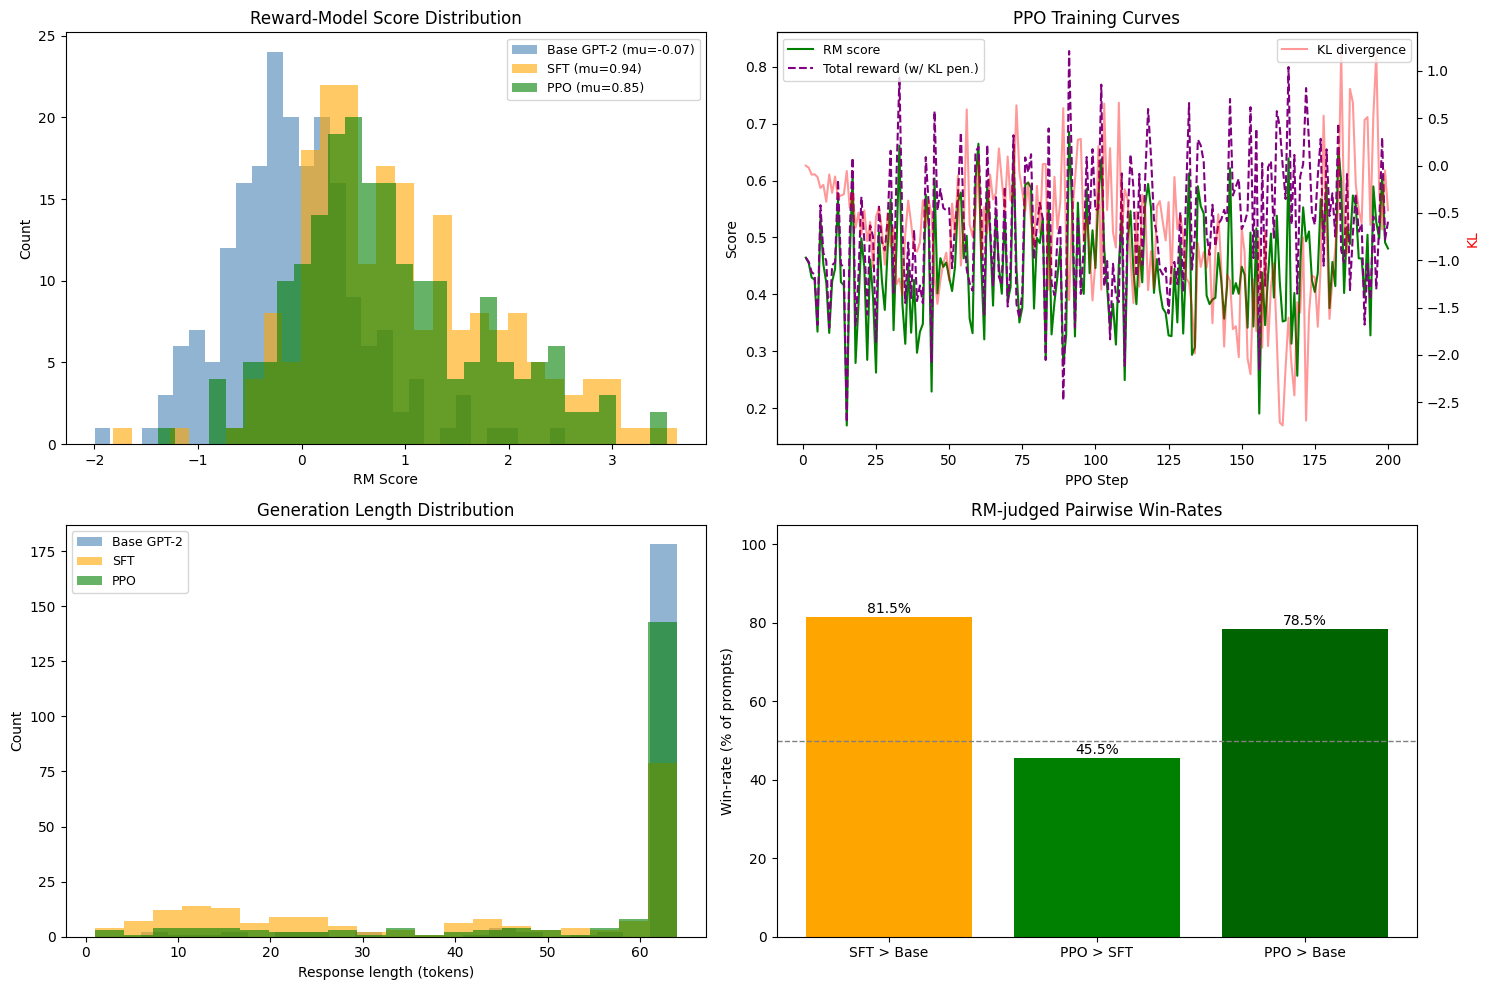

Plots saved.


In [33]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
ax1, ax2, ax3, ax4 = axes.flat

# RM score histogram
for scores, label, color in [
    (base_sc, f"Base GPT-2 (mu={np.mean(base_sc):.2f})", "steelblue"),
    (sft_sc,  f"SFT (mu={np.mean(sft_sc):.2f})",         "orange"),
    (ppo_sc,  f"PPO (mu={np.mean(ppo_sc):.2f})",         "green"),
]:
    ax1.hist(scores, bins=30, alpha=0.6, label=label, color=color)
ax1.set_xlabel("RM Score"); ax1.set_ylabel("Count")
ax1.set_title("Reward-Model Score Distribution"); ax1.legend(fontsize=9)

# PPO training curves
if ppo_log:
    steps   = [m["ppo/step"]     for m in ppo_log]
    rm_vals = [m["ppo/rm_score"] for m in ppo_log]
    tot_r   = [m["ppo/reward"]   for m in ppo_log]
    kl_vals = [m["ppo/kl"]       for m in ppo_log]
    ax2.plot(steps, rm_vals, label="RM score", color="green")
    ax2.plot(steps, tot_r,   label="Total reward (w/ KL pen.)", color="purple", ls="--")
    ax2.set_xlabel("PPO Step"); ax2.set_ylabel("Score")
    ax2.set_title("PPO Training Curves"); ax2.legend(loc="upper left", fontsize=9)
    ax2b = ax2.twinx()
    ax2b.plot(steps, kl_vals, color="red", alpha=0.4, label="KL divergence")
    ax2b.set_ylabel("KL", color="red"); ax2b.legend(loc="upper right", fontsize=9)

# Generation-length distribution
for lens, label, color in [
    (base_len, "Base GPT-2", "steelblue"),
    (sft_len,  "SFT",        "orange"),
    (ppo_len,  "PPO",        "green"),
]:
    ax3.hist(lens, bins=20, alpha=0.6, label=label, color=color)
ax3.set_xlabel("Response length (tokens)"); ax3.set_ylabel("Count")
ax3.set_title("Generation Length Distribution"); ax3.legend(fontsize=9)

# Win-rate bar chart
labels  = ["SFT > Base", "PPO > SFT", "PPO > Base"]
winrates = [wr_sft_base[0], wr_ppo_sft[0], wr_ppo_base[0]]
bars = ax4.bar(labels, [w*100 for w in winrates],
               color=["orange", "green", "darkgreen"])
ax4.axhline(50, color="grey", ls="--", lw=1)
ax4.set_ylabel("Win-rate (% of prompts)")
ax4.set_title("RM-judged Pairwise Win-Rates")
for b, w in zip(bars, winrates):
    ax4.text(b.get_x() + b.get_width()/2, b.get_height() + 1,
             f"{w*100:.1f}%", ha="center", fontsize=10)
ax4.set_ylim(0, 105)

plt.tight_layout()
plt.savefig("evaluation.png", dpi=150, bbox_inches="tight")
wandb.log({"eval/score_distribution": wandb.Image("evaluation.png")})
plt.show()
print("Plots saved.")


## PPO checkpoint scan — was step-60 actually better?  ⟨ppo-scan-extension⟩

The original PPO loop saved **only the final-step model**, so we cannot directly compare
the peak (~step 60) against the saved final (step 200).

Workaround: re-run PPO **with the same hyperparameters** but checkpointing every 20 steps,
then score every checkpoint on a **fixed** set of 80 Alpaca prompts using `reward_model`
(the same RM PPO optimised against).

**Caveat — stochasticity.** The original run set no global seed; we set one here so this
re-run is reproducible. The trajectory will differ in numerical detail from the original
(±0.1 in RM score per step is typical), but the qualitative shape (early peak, late drift
as KL grows) should reproduce if the original observation was real.

Artifacts:
- Checkpoints → `./checkpoints/ppo_model_scan/step_NNN.pt` (actor state-dict only, ~500 MB each)
- A plot of RM mean vs PPO step, with SFT baseline and the original final-PPO model overlaid


In [34]:
# PPO_SCAN_BLOCK — re-run PPO from SFT with seeding + intermediate checkpointing.
import os, random, math
import numpy as np
import torch

SCAN_SEED       = 2026
SCAN_CKPT_EVERY = 20
scan_dir = os.path.join(cfg.output_dir, "ppo_model_scan")
os.makedirs(scan_dir, exist_ok=True)

# Detect a completed prior scan (≥10 checkpoints) and skip if so
existing = sorted(int(f[5:8]) for f in os.listdir(scan_dir) if f.startswith("step_") and f.endswith(".pt"))
if len(existing) >= 10:
    print(f"Found {len(existing)} existing scan checkpoints in {scan_dir} — skipping re-run.")
    ckpt_paths = {s: os.path.join(scan_dir, f"step_{s:03d}.pt") for s in existing}
    # ppo_log_scan won't be available without re-running; downstream cell handles that.
    ppo_log_scan = globals().get("ppo_log_scan", [])
else:
    # --- Snapshot global RNG state so this re-run doesn't perturb downstream cells
    _rng_py    = random.getstate()
    _rng_np    = np.random.get_state()
    _rng_t     = torch.get_rng_state()
    _rng_t_cu  = torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None

    random.seed(SCAN_SEED); np.random.seed(SCAN_SEED); torch.manual_seed(SCAN_SEED)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(SCAN_SEED)

    # Fresh ActorCritic from SFT (don't disturb the existing post-PPO `actor_critic`)
    ac_scan  = ActorCritic(GPT2LMHeadModel.from_pretrained(sft_path).to(device)).to(device)
    opt_scan = AdamW(ac_scan.parameters(), lr=cfg.ppo_lr, weight_decay=0.01)
    print(f"Re-initialised ActorCritic from SFT (seed={SCAN_SEED}).")

    # `collect_rollout` and `ppo_step` look up `actor_critic` / `ppo_optimizer` as globals.
    # Swap them temporarily; restore in finally.
    _orig_ac   = globals()["actor_critic"]
    _orig_opt  = globals()["ppo_optimizer"]
    globals()["actor_critic"]  = ac_scan
    globals()["ppo_optimizer"] = opt_scan

    ckpt_paths = {}
    ppo_log_scan = []
    print(f"PPO scan: {cfg.ppo_steps} steps × {cfg.ppo_epochs} inner epochs, "
          f"batch={cfg.ppo_batch_size}, ckpt every {SCAN_CKPT_EVERY}")
    try:
        for step in range(1, cfg.ppo_steps + 1):
            batch_prompts = random.sample(ppo_prompts, cfg.ppo_batch_size)
            rollout = collect_rollout(batch_prompts)
            inner_metrics = []
            for _ in range(cfg.ppo_epochs):
                m = ppo_step(rollout)
                inner_metrics.append(m)
                if m["approx_kl"] > 1.5 * cfg.kl_coef:
                    break
            avg = {k: float(np.mean([mm[k] for mm in inner_metrics])) for k in inner_metrics[0]}
            log = {
                "step":       step,
                "rm_score":   rollout["rm_scores"].mean().item(),
                "kl":         rollout["kl"].mean().item(),
                "reward":     rollout["rewards"].mean().item(),
                "actor_loss": avg["actor_loss"],
                "approx_kl":  avg["approx_kl"],
            }
            ppo_log_scan.append(log)
            if step == 1 or step % SCAN_CKPT_EVERY == 0:
                ck_path = os.path.join(scan_dir, f"step_{step:03d}.pt")
                torch.save(ac_scan.actor.state_dict(), ck_path)
                ckpt_paths[step] = ck_path
                print(f"  step {step:4d} | rm={log['rm_score']:+.3f}  kl={log['kl']:.2f}  "
                      f"→ {os.path.basename(ck_path)}")
    finally:
        # Restore globals + RNG so subsequent cells see the same world as before
        globals()["actor_critic"]  = _orig_ac
        globals()["ppo_optimizer"] = _orig_opt
        random.setstate(_rng_py); np.random.set_state(_rng_np); torch.set_rng_state(_rng_t)
        if _rng_t_cu is not None: torch.cuda.set_rng_state_all(_rng_t_cu)

    print(f"\nPPO scan done. {len(ckpt_paths)} checkpoints saved to {scan_dir}")


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Re-initialised ActorCritic from SFT (seed=2026).
PPO scan: 200 steps × 4 inner epochs, batch=32, ckpt every 20
  step    1 | rm=+0.464  kl=0.00  → step_001.pt
  step   20 | rm=+0.567  kl=-1.01  → step_020.pt
  step   40 | rm=+0.774  kl=-1.24  → step_040.pt
  step   60 | rm=+0.624  kl=-0.41  → step_060.pt
  step   80 | rm=+0.653  kl=-1.21  → step_080.pt
  step  100 | rm=+0.449  kl=0.07  → step_100.pt
  step  120 | rm=+0.347  kl=0.21  → step_120.pt
  step  140 | rm=+0.621  kl=0.28  → step_140.pt
  step  160 | rm=+0.437  kl=0.02  → step_160.pt
  step  180 | rm=+0.407  kl=0.16  → step_180.pt
  step  200 | rm=+0.319  kl=1.19  → step_200.pt

PPO scan done. 11 checkpoints saved to ./checkpoints/ppo_model_scan


Scoring on 80 fixed prompts using reward_model (rm.pt).


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Scoring SFT baseline...


scoring:   0%|          | 0/80 [00:00<?, ?it/s]

...

Loading scan ckpt step=180...


scoring:   0%|          | 0/80 [00:00<?, ?it/s]

Loading scan ckpt step=200...


scoring:   0%|          | 0/80 [00:00<?, ?it/s]


  step     RM mean    RM std   len mean    vs SFT
   SFT      +0.910     0.808       42.0    (base)
     1      +0.825     0.753       44.9    -0.085
    20      +0.825     0.869       48.5    -0.085
    40      +0.755     0.821       51.3    -0.154
    60      +0.682     0.804       51.9    -0.228
    80      +0.790     0.788       52.5    -0.119
   100      +0.657     0.756       51.6    -0.252
   120      +0.863     0.804       50.2    -0.047
   140      +0.644     0.801       46.6    -0.266
   160      +0.704     0.923       47.8    -0.206
   180      +0.868     0.859       49.5    -0.042
   200      +0.904     0.808       45.4    -0.006
  orig      +0.600     0.791       53.9    -0.310   (the saved final-PPO model)

Peak: step 200  RM mean = +0.904  (saved-final step 200 = +0.904)


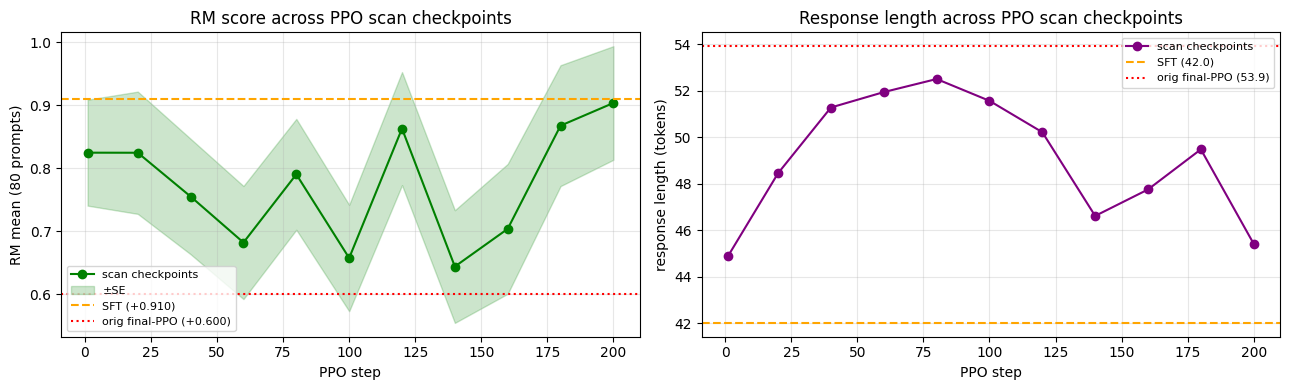


VERDICT: peak and final are within noise — collapse hypothesis NOT confirmed in this re-run. The original step-60 spike was likely sampling noise on a 32-prompt batch.


In [35]:
# Score every scan checkpoint + SFT baseline + original final PPO on the SAME 80 prompts.
import os, random
import numpy as np
import matplotlib.pyplot as plt
import torch

EVAL_N = 80
# Deterministic prompt pick — independent of any earlier RNG state
_rs = random.Random(20260512)
fixed_prompts = _rs.sample(ppo_prompts, min(EVAL_N, len(ppo_prompts)))
print(f"Scoring on {len(fixed_prompts)} fixed prompts using reward_model (rm.pt).")

reward_model.eval()
_eval_model = GPT2LMHeadModel.from_pretrained(cfg.model_name).to(device)  # scratchpad
_eval_model.config.pad_token_id = tokenizer.eos_token_id

@torch.no_grad()
def _score_model(model):
    model.eval()
    sc, ln = [], []
    for prompt_str in tqdm(fixed_prompts, desc="scoring", leave=False):
        lines = prompt_str.split("\n")
        inst  = lines[1] if len(lines) > 1 else prompt_str
        resp  = generate(model, inst, max_new_tokens=cfg.max_new_tokens, temperature=0.9)
        full  = prompt_str + resp
        enc   = tokenizer(full, return_tensors="pt", max_length=512, truncation=True).to(device)
        sc.append(reward_model(enc["input_ids"], enc["attention_mask"]).item())
        ln.append(len(tokenizer.encode(resp)))
    return np.array(sc), np.array(ln)

# --- Baselines: SFT and the original-run final PPO ---
sft_baseline = GPT2LMHeadModel.from_pretrained(sft_path).to(device)
sft_baseline.config.pad_token_id = tokenizer.eos_token_id
print("Scoring SFT baseline...")
sft_sc_scan, sft_ln_scan = _score_model(sft_baseline)
del sft_baseline; torch.cuda.empty_cache()

orig_ppo_path = os.path.join(cfg.output_dir, "ppo_model")
if os.path.isdir(orig_ppo_path):
    print("Scoring original final-PPO (from checkpoints/ppo_model)...")
    orig_ppo = GPT2LMHeadModel.from_pretrained(orig_ppo_path).to(device)
    orig_ppo.config.pad_token_id = tokenizer.eos_token_id
    orig_sc_scan, orig_ln_scan = _score_model(orig_ppo)
    del orig_ppo; torch.cuda.empty_cache()
else:
    orig_sc_scan = orig_ln_scan = None

# --- Sweep all scan checkpoints ---
results = []
for step in sorted(ckpt_paths.keys()):
    print(f"Loading scan ckpt step={step}...")
    state = torch.load(ckpt_paths[step], map_location=device)
    _eval_model.load_state_dict(state)
    sc, ln = _score_model(_eval_model)
    results.append({"step": step, "rm_mean": float(sc.mean()), "rm_std": float(sc.std()),
                    "len_mean": float(ln.mean()), "len_std": float(ln.std()),
                    "rm_arr": sc, "len_arr": ln})

# --- Print table ---
print(f"\n{'step':>6}  {'RM mean':>10}  {'RM std':>8}  {'len mean':>9}  {'vs SFT':>8}")
print(f"{'SFT':>6}  {sft_sc_scan.mean():>+10.3f}  {sft_sc_scan.std():>8.3f}  {sft_ln_scan.mean():>9.1f}  {'(base)':>8}")
for r in results:
    delta = r["rm_mean"] - sft_sc_scan.mean()
    print(f"{r['step']:>6}  {r['rm_mean']:>+10.3f}  {r['rm_std']:>8.3f}  {r['len_mean']:>9.1f}  {delta:>+8.3f}")
if orig_sc_scan is not None:
    print(f"{'orig':>6}  {orig_sc_scan.mean():>+10.3f}  {orig_sc_scan.std():>8.3f}  {orig_ln_scan.mean():>9.1f}  "
          f"{orig_sc_scan.mean() - sft_sc_scan.mean():>+8.3f}   (the saved final-PPO model)")

best = max(results, key=lambda r: r["rm_mean"])
print(f"\nPeak: step {best['step']}  RM mean = {best['rm_mean']:+.3f}  "
      f"(saved-final step {results[-1]['step']} = {results[-1]['rm_mean']:+.3f})")

# --- Plot trajectory ---
fig, (axa, axb) = plt.subplots(1, 2, figsize=(13, 4))
steps_arr = np.array([r["step"] for r in results])
rms       = np.array([r["rm_mean"] for r in results])
rmstd     = np.array([r["rm_std"]  for r in results])
lens      = np.array([r["len_mean"] for r in results])

axa.plot(steps_arr, rms, marker="o", color="green", label="scan checkpoints")
axa.fill_between(steps_arr, rms - rmstd / np.sqrt(EVAL_N), rms + rmstd / np.sqrt(EVAL_N),
                 alpha=0.2, color="green", label="±SE")
axa.axhline(sft_sc_scan.mean(), color="orange", ls="--", label=f"SFT ({sft_sc_scan.mean():+.3f})")
if orig_sc_scan is not None:
    axa.axhline(orig_sc_scan.mean(), color="red", ls=":", label=f"orig final-PPO ({orig_sc_scan.mean():+.3f})")
axa.set_xlabel("PPO step"); axa.set_ylabel("RM mean (80 prompts)")
axa.set_title("RM score across PPO scan checkpoints"); axa.legend(fontsize=8); axa.grid(alpha=0.3)

axb.plot(steps_arr, lens, marker="o", color="purple", label="scan checkpoints")
axb.axhline(sft_ln_scan.mean(), color="orange", ls="--", label=f"SFT ({sft_ln_scan.mean():.1f})")
if orig_ln_scan is not None:
    axb.axhline(orig_ln_scan.mean(), color="red", ls=":", label=f"orig final-PPO ({orig_ln_scan.mean():.1f})")
axb.set_xlabel("PPO step"); axb.set_ylabel("response length (tokens)")
axb.set_title("Response length across PPO scan checkpoints"); axb.legend(fontsize=8); axb.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# --- Verdict
verdict_peak  = best['rm_mean']
verdict_final = results[-1]['rm_mean']
verdict_orig  = orig_sc_scan.mean() if orig_sc_scan is not None else None
print()
if verdict_peak - verdict_final > 0.05:
    print(f"VERDICT: peak (step {best['step']}, RM {verdict_peak:+.3f}) is meaningfully better than "
          f"the saved-final scan (step {results[-1]['step']}, {verdict_final:+.3f}). "
          f"Confirms the 'collapse after step ~{best['step']}' hypothesis.")
elif abs(verdict_peak - verdict_final) <= 0.05:
    print(f"VERDICT: peak and final are within noise — collapse hypothesis NOT confirmed in this re-run. "
          f"The original step-60 spike was likely sampling noise on a 32-prompt batch.")
else:
    print(f"VERDICT: scan-final is actually higher than the scan peak — re-run didn't reproduce collapse.")


---
## Summary

| Stage | Objective | Dataset | Epochs | Key technique |
|-------|-----------|---------|--------|---------------|
| **SFT** | Imitate demonstrations | Alpaca 52 K | 8 | Response-only cross-entropy |
| **RM** | Rank responses | HH-RLHF 170 K | 1 | Bradley-Terry pairwise loss |
| **PPO** | Maximise RM under KL | Alpaca prompts | 100 steps | Clipped surrogate + KL penalty |

### Key Design Choices

1. **Response-only SFT loss** — prompt labels → −100; only output quality matters
2. **RM init from SFT** — backbone already understands language; fine-tune the head
3. **1 epoch for RM** — preference data is scarce; more epochs → overfitting
4. **KL penalty β** — prevents reward hacking without constraining too tightly
5. **PPO-ptx** — InstructGPT also mixes pretraining gradient to preserve capabilities

### Known Limitations

- **Reward hacking**: policy can exploit RM blind spots
- **RM distribution shift**: RM trained on SFT outputs, tested on PPO outputs
- **Annotation cost**: real labelling is expensive; we simulate with HH-RLHF
- **Scale**: true InstructGPT uses 1.3 B–175 B; GPT-2 shows the *mechanics*, not the quality

### Further Reading

- InstructGPT: https://arxiv.org/abs/2203.02155
- HuggingFace TRL library: https://github.com/huggingface/trl
- OpenRLHF: https://github.com/OpenRLHF/OpenRLHF
- RLHF blog (Hugging Face): https://huggingface.co/blog/rlhf


In [36]:
wandb.finish()
print("All done! wandb run finished.")


diag/dist_shift_eff,▁
diag/sched_filter_eff,▁
diag/tok_effect,▁
eval/rm_mean_base,▁
eval/rm_mean_ppo,▁
eval/rm_mean_sft,▁
eval/winrate_ppo_vs_base,▁
eval/winrate_ppo_vs_sft,▁
eval/winrate_sft_vs_base,▁
ppo/actor_loss,▂▂▂▂▂▃█▁▃▂▂▁▂▂▁▂▂▂▂▁▂▂▂▂▂▁▁▂▂▅▂▃▂▂▂▃▁▃▂▃
+17,...


All done! wandb run finished.
